In [16]:
# Importamos la base de datos palmer penguins
import pandas as pd
import seaborn as sns
penguins = sns.load_dataset("penguins")

# Mostramos las primeras filas del DataFrame
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [18]:
# Eliminar los valores nulos
penguins = penguins.dropna()

X = penguins.drop(columns=['species'])
y = penguins['species']

# Mapeo la columna 'sex' a valores numéricos
X['sex'] = X['sex'].map({'Male': 0, 'Female': 1})

# Mapeo la columna 'island' a valores numéricos
X['island'] = X['island'].map({'Biscoe': 0, 'Dream': 1, 'Torgersen': 2})

X.head()

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,2,39.1,18.7,181.0,3750.0,0
1,2,39.5,17.4,186.0,3800.0,1
2,2,40.3,18.0,195.0,3250.0,1
4,2,36.7,19.3,193.0,3450.0,1
5,2,39.3,20.6,190.0,3650.0,0


In [19]:
# Estandarizamos las características numéricas
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() 
X[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']] = scaler.fit_transform(X[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']])
# Mostramos las primeras filas de las características procesadas
X.head()

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,2,-0.896042,0.780732,-1.426752,-0.568475,0
1,2,-0.822788,0.119584,-1.069474,-0.506286,1
2,2,-0.676280,0.424729,-0.426373,-1.190361,1
4,2,-1.335566,1.085877,-0.569284,-0.941606,1
5,2,-0.859415,1.747026,-0.783651,-0.692852,0


In [20]:
y.value_counts()

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        31
   Chinstrap       1.00      1.00      1.00        13
      Gentoo       1.00      1.00      1.00        23

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



/Users/eugenio/Documents/Notebooks_ArtificialIntelligence/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


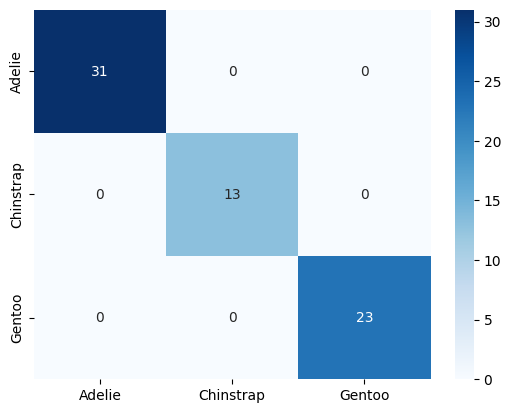

In [ ]:
# Entrenar un modelo MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Dividimos los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creamos y entrenamos el modelo
model = MLPClassifier(hidden_layer_sizes=(100,), random_state=42)
model.fit(X_train, y_train)

# Hacemos predicciones
y_pred = model.predict(X_test)
# Evaluamos el modelo
conf = confusion_matrix(y_test, y_pred)
sns.heatmap(conf, annot=True, cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
print(classification_report(y_test, y_pred))

In [22]:
# Guardar el modelo entrenado
import joblib
joblib.dump(model, 'mlp_classifier_penguins.joblib')

['mlp_classifier_penguins.joblib']

In [23]:
# Cargo el modelo guardado
modelo_cargado = joblib.load('mlp_classifier_penguins.joblib')

In [26]:
# Defino un nuevo pingüino para predecir su especie
nuevo_pingüino = pd.DataFrame({
    'island': [0],  # Biscoe,
    'bill_length_mm': [50.0],
    'bill_depth_mm': [15.0],
    'flipper_length_mm': [200.0],
    'body_mass_g': [4000.0],
    'sex': [0]    # Male
})

# Estandarizo las características numéricas del nuevo pingüino
nuevo_pingüino[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']] = scaler.transform(nuevo_pingüino[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']])
nuevo_pingüino.head()


,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,0,1.10013,-1.100997,-0.069095,-0.257532,0


In [27]:
# Hago la predicción
predicción = modelo_cargado.predict(nuevo_pingüino)
print(f'La especie predicha del nuevo pingüino es: {predicción[0]}')


La especie predicha del nuevo pingüino es: Gentoo


In [28]:
# Exporto los pesos de cada capa a archivos .xlsx
import numpy as np
import pandas as pd
for i, coef in enumerate(model.coefs_):
    df = pd.DataFrame(coef)
    df.to_excel(f'layer_{i+1}_weights.xlsx', index=False)


In [29]:
# Exporto los sesgos de cada capa a archivos .xlsx
for i, intercept in enumerate(model.intercepts_):
    df = pd.DataFrame(intercept, columns=['bias'])
    df.to_excel(f'layer_{i+1}_biases.xlsx', index=False)